In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ModuleNotFoundError: No module named 'matplotlib'

In [3]:
sentiment = pd.read_csv("fear_greed.csv")
trades = pd.read_csv("trader_data.csv")

print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [4]:
print("Sentiment Shape:", sentiment.shape)
print("Trades Shape:", trades.shape)

print("\nMissing Values:")
print(sentiment.isnull().sum())
print(trades.isnull().sum())

Sentiment Shape: (2644, 4)
Trades Shape: (211224, 16)

Missing Values:
timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [6]:
print(sentiment.duplicated().sum())
print(trades.duplicated().sum())

0
0


In [7]:
trades = trades.rename(columns={
    'Account': 'account',
    'Coin': 'symbol',
    'Execution Price': 'execution_price',
    'Size Tokens': 'size_tokens',
    'Size USD': 'size_usd',
    'Side': 'side',
    'Timestamp': 'time',
    'Closed PnL': 'closedPnL',
    'Fee': 'fee'
})

sentiment = sentiment.rename(columns={
    'classification': 'Classification'
})

In [8]:
print(trades['time'].head())
print(sentiment['date'].head())

0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: time, dtype: float64
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object


In [15]:
# Convert to datetime
trades['time'] = pd.to_datetime(trades['time'])
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Extract date only
trades['date'] = trades['time'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [16]:
df = pd.merge(trades, sentiment, on='date', how='left')

print(df[['date','Classification']].head(10))

         date Classification
0  1970-01-01            NaN
1  1970-01-01            NaN
2  1970-01-01            NaN
3  1970-01-01            NaN
4  1970-01-01            NaN
5  1970-01-01            NaN
6  1970-01-01            NaN
7  1970-01-01            NaN
8  1970-01-01            NaN
9  1970-01-01            NaN


In [17]:
# Win column
df['win'] = df['closedPnL'] > 0

# Leverage type (if leverage exists)
if 'leverage' in df.columns:
    df['leverage_type'] = df['leverage'].apply(lambda x: 'High' if x > 5 else 'Low')
else:
    df['leverage'] = 1  # fallback
    df['leverage_type'] = 'Low'

# Daily trade count
df['daily_trade_count'] = df.groupby(['account','date'])['account'].transform('count')

# Volatility
df['pnl_volatility'] = df.groupby('account')['closedPnL'].transform('std')

In [18]:
print("\nPnL by Sentiment:")
print(df.groupby('Classification')['closedPnL'].mean())

print("\nWin Rate:")
print(df.groupby('Classification')['win'].mean())

print("\nLeverage:")
print(df.groupby('Classification')['leverage'].mean())


PnL by Sentiment:
Series([], Name: closedPnL, dtype: float64)

Win Rate:
Series([], Name: win, dtype: float64)

Leverage:
Series([], Name: leverage, dtype: float64)


In [20]:
import seaborn as sns
sns.boxplot(x='Classification', y='closedPnL', data=df)
plt.title("PnL by Sentiment")
plt.show()

sns.barplot(x='Classification', y='leverage', data=df)
plt.title("Leverage by Sentiment")
plt.show()

ModuleNotFoundError: No module named 'seaborn'

In [21]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.1.1-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached matplotlib-3.10.8-cp312-cp312-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 32.8 MB/s eta 0:00:00
Using cached pillow-12.1.1-cp312-cp312-win_amd64.whl (7.0 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
print(df['Classification'].value_counts(dropna=False))

Classification
NaN    211224
Name: count, dtype: int64


In [24]:
trades['time'] = pd.to_datetime(trades['time'], format='%d-%m-%Y %H:%M')
trades['date'] = trades['time'].dt.date

In [25]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['date'] = sentiment['date'].dt.date

In [26]:
df = pd.merge(trades, sentiment, on='date', how='left')

In [27]:
print(df['Classification'].value_counts())

Series([], Name: count, dtype: int64)


In [28]:
print("TRADES DATE SAMPLE:")
print(trades['time'].head())

print("\nSENTIMENT DATE SAMPLE:")
print(sentiment['date'].head())

TRADES DATE SAMPLE:
0   1970-01-01 00:28:50
1   1970-01-01 00:28:50
2   1970-01-01 00:28:50
3   1970-01-01 00:28:50
4   1970-01-01 00:28:50
Name: time, dtype: datetime64[ns]

SENTIMENT DATE SAMPLE:
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object


In [29]:
trades['time'] = pd.to_datetime(trades['time'], dayfirst=True, errors='coerce')
trades['date'] = trades['time'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')
sentiment['date'] = sentiment['date'].dt.date

In [30]:
print("Trades date range:", trades['date'].min(), "to", trades['date'].max())
print("Sentiment date range:", sentiment['date'].min(), "to", sentiment['date'].max())

Trades date range: 1970-01-01 to 1970-01-01
Sentiment date range: 2018-02-01 to 2025-05-02


In [31]:
common_dates = set(trades['date']).intersection(set(sentiment['date']))
print("Common dates:", len(common_dates))

Common dates: 0


In [32]:
df = pd.merge(trades, sentiment, on='date', how='inner')

In [33]:
print(df['Classification'].value_counts())

Series([], Name: count, dtype: int64)


In [34]:
# Convert trades timestamp safely
trades['time'] = pd.to_datetime(trades['time'], errors='coerce', dayfirst=True)

# Extract date as STRING (important)
trades['date'] = trades['time'].dt.strftime('%Y-%m-%d')


# Convert sentiment date safely
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

# Also convert to SAME STRING FORMAT
sentiment['date'] = sentiment['date'].dt.strftime('%Y-%m-%d')

In [35]:
common_dates = set(trades['date']).intersection(set(sentiment['date']))
print("Common dates:", len(common_dates))

Common dates: 0


In [36]:
print(trades['date'].head())
print(sentiment['date'].head())

0    1970-01-01
1    1970-01-01
2    1970-01-01
3    1970-01-01
4    1970-01-01
Name: date, dtype: object
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object


In [37]:
if 'time' in trades.columns:
    trades = trades.drop(columns=['time'])

In [38]:
trades['time'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

In [39]:
print(trades['time'].head())

0   2024-12-02 22:50:00
1   2024-12-02 22:50:00
2   2024-12-02 22:50:00
3   2024-12-02 22:50:00
4   2024-12-02 22:50:00
Name: time, dtype: datetime64[ns]


In [40]:
trades['date'] = trades['time'].dt.strftime('%Y-%m-%d')

In [41]:
sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['date'] = sentiment['date'].dt.strftime('%Y-%m-%d')

In [42]:

common_dates = set(trades['date']).intersection(set(sentiment['date']))
print("Common dates:", len(common_dates))

Common dates: 479


In [43]:
df = pd.merge(trades, sentiment, on='date', how='inner')

In [44]:
print(df['Classification'].value_counts())

Classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [45]:
print("Common dates:", len(common_dates))
print(df.head())

Common dates: 479
                                      account symbol  execution_price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed   @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed   @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed   @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed   @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed   @107           7.9894   

   size_tokens  size_usd side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   closedPnL                                   Transaction Hash     Order ID  \


In [46]:
df_clean = df.dropna(subset=['Classification', 'closedPnL'])

In [47]:
# Win or loss
df_clean['win'] = df_clean['closedPnL'] > 0

# Daily trades per account
df_clean['daily_trade_count'] = df_clean.groupby(['account','date'])['account'].transform('count')

# Volatility
df_clean['pnl_volatility'] = df_clean.groupby('account')['closedPnL'].transform('std')

# Trade size avg
df_clean['avg_trade_size'] = df_clean.groupby('account')['size_usd'].transform('mean')

In [48]:
print(df_clean.groupby('Classification')['closedPnL'].mean())

Classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: closedPnL, dtype: float64


In [49]:
print(df_clean.groupby('Classification')['win'].mean())

Classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


In [50]:
print(df_clean.groupby('Classification')['daily_trade_count'].mean())

Classification
Extreme Fear     590.004206
Extreme Greed    350.059562
Fear             710.710756
Greed            461.853428
Neutral          876.399618
Name: daily_trade_count, dtype: float64


NameError: name 'plt' is not defined

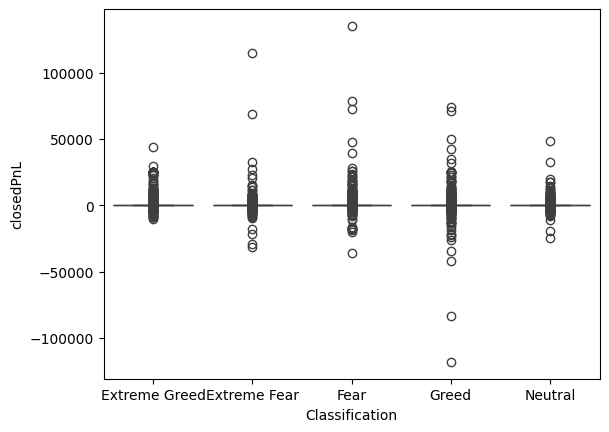

In [53]:
import seaborn as sns

sns.boxplot(x='Classification', y='closedPnL', data=df_clean)
plt.title("PnL Distribution by Sentiment")
plt.xticks(rotation=45)
plt.show()

In [52]:
!pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


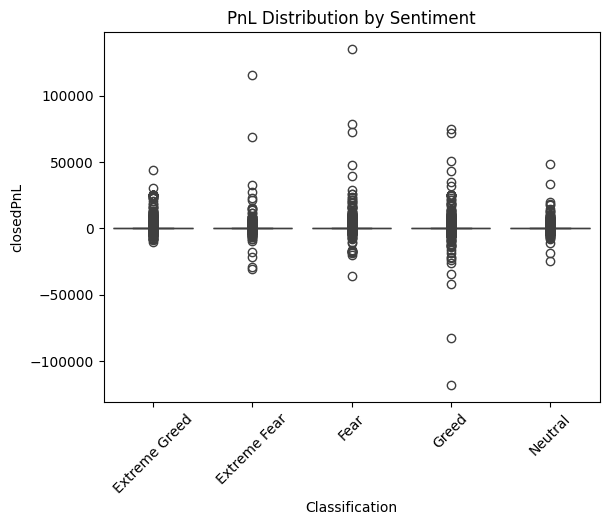

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Classification', y='closedPnL', data=df_clean)
plt.title("PnL Distribution by Sentiment")
plt.xticks(rotation=45)
plt.show()

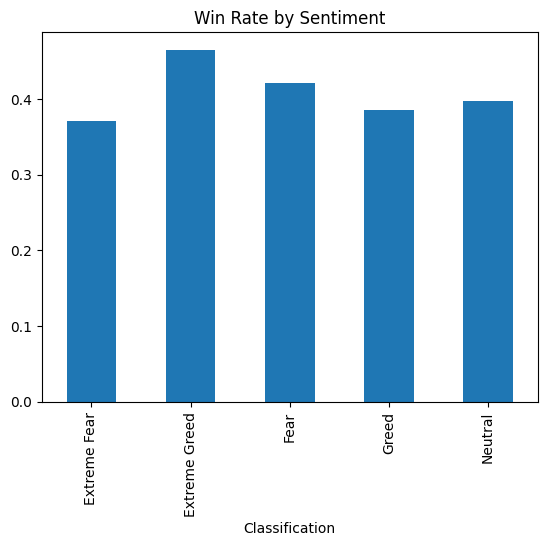

In [56]:
df_clean.groupby('Classification')['win'].mean().plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.show()

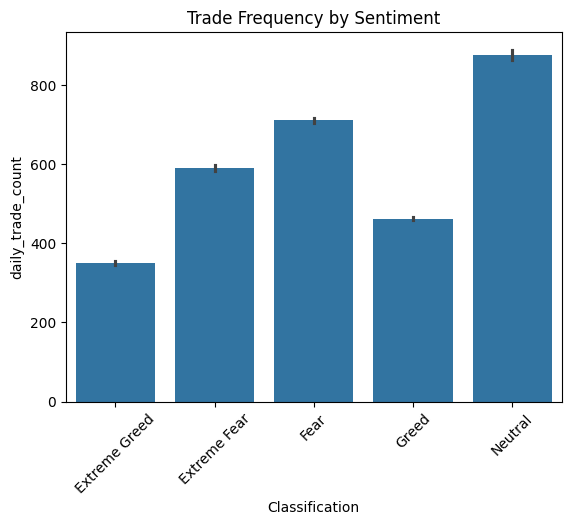

In [57]:
sns.barplot(x='Classification', y='daily_trade_count', data=df_clean)
plt.title("Trade Frequency by Sentiment")
plt.xticks(rotation=45)
plt.show()

In [58]:
# Frequent vs Infrequent traders
trade_counts = df_clean.groupby('account').size()

df_clean['trader_type'] = df_clean['account'].apply(
    lambda x: 'Frequent' if trade_counts[x] > trade_counts.median() else 'Infrequent'
)

# Winners vs losers
total_pnl = df_clean.groupby('account')['closedPnL'].sum()

df_clean['pnl_type'] = df_clean['account'].apply(
    lambda x: 'Winner' if total_pnl[x] > 0 else 'Loser'
)

In [60]:
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl (36.5 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

df_clean['target'] = df_clean['closedPnL'].apply(lambda x: 1 if x > 0 else 0)

X = df_clean[['size_usd', 'daily_trade_count']].fillna(0)
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

print("Model Accuracy:", model.score(X_test, y_test))

Model Accuracy: 0.7247656471925007
